# Tutorial 25: Accessing Intermediate Derivatives

In complex computations, you often need derivatives not just of the final output, but of **intermediate values** within the computation. This tutorial covers:

1. `has_aux` - Return intermediates alongside gradients
2. `value_and_grad` - Get both value and gradient
3. Jacobians of intermediate quantities
4. Gradient checkpointing with intermediate access
5. Custom VJP for intermediate gradients
6. Sensitivity of intermediates to parameters
7. Chemical engineering example: Reactor cascade analysis

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jacobian, vmap, jit, value_and_grad
from jax import custom_vjp
from functools import partial
import matplotlib.pyplot as plt

jax.config.update('jax_enable_x64', True)

## 1. The `has_aux` Pattern

The most common way to get intermediate values during gradient computation is using `has_aux=True`. Your function returns `(output, auxiliary_data)`, and JAX differentiates only through `output`.

In [2]:
# Basic has_aux example
def computation_with_intermediates(x):
    """A multi-step computation where we want intermediate values."""
    h1 = jnp.sin(x)           # First intermediate
    h2 = h1 ** 2              # Second intermediate
    h3 = jnp.exp(-h2)         # Third intermediate
    output = h3.sum()         # Final scalar output
    
    # Return output AND intermediates
    intermediates = {'h1': h1, 'h2': h2, 'h3': h3}
    return output, intermediates

# Create gradient function that returns auxiliaries
grad_fn = grad(lambda x: computation_with_intermediates(x)[0], has_aux=True)

# But wait - this doesn't work as expected!
# has_aux expects the function itself to return (value, aux)

# Correct approach:
def grad_with_aux(f):
    """Wrapper to get gradients with auxiliary outputs."""
    def f_for_grad(x):
        out, aux = f(x)
        return out, aux
    return grad(f_for_grad, has_aux=True)

# Test
x = jnp.array([0.5, 1.0, 1.5])
gradient, intermediates = grad(computation_with_intermediates, has_aux=True)(x)

print("Input x:", x)
print("\nIntermediate values:")
for name, value in intermediates.items():
    print(f"  {name}: {value}")
print(f"\nGradient d(output)/dx: {gradient}")

Input x: [0.5 1.  1.5]

Intermediate values:
  h1: [0.47942554 0.84147098 0.99749499]
  h2: [0.22984885 0.70807342 0.99499625]
  h3: [0.79465371 0.4925923  0.36972483]

Gradient d(output)/dx: [-0.66867804 -0.44791291 -0.05217557]


In [3]:
# Practical example: Neural network with intermediate activations
def mlp_with_activations(params, x):
    """MLP that returns both output and all intermediate activations."""
    activations = {'input': x}
    
    h = x
    for i, (W, b) in enumerate(zip(params['W'], params['b'])):
        pre_activation = h @ W + b
        activations[f'pre_act_{i}'] = pre_activation
        
        if i < len(params['W']) - 1:  # Hidden layers
            h = jnp.tanh(pre_activation)
            activations[f'post_act_{i}'] = h
        else:  # Output layer (no activation)
            h = pre_activation
    
    return h, activations

# Initialize a small network
key = jax.random.PRNGKey(0)
params = {
    'W': [jax.random.normal(key, (4, 8)) * 0.1,
          jax.random.normal(jax.random.PRNGKey(1), (8, 8)) * 0.1,
          jax.random.normal(jax.random.PRNGKey(2), (8, 2)) * 0.1],
    'b': [jnp.zeros(8), jnp.zeros(8), jnp.zeros(2)]
}

x = jax.random.normal(jax.random.PRNGKey(3), (4,))

# Forward pass with activations
output, activations = mlp_with_activations(params, x)

print("MLP Intermediate Activations:")
print("=" * 50)
for name, act in activations.items():
    print(f"{name:>15}: shape={act.shape}, mean={act.mean():.4f}, std={act.std():.4f}")
print(f"\nOutput: {output}")

MLP Intermediate Activations:


          input: shape=(4,), mean=-0.1376, std=0.7661


      pre_act_0: shape=(8,), mean=0.0574, std=0.1018
     post_act_0: shape=(8,), mean=0.0568, std=0.1010
      pre_act_1: shape=(8,), mean=0.0055, std=0.0338
     post_act_1: shape=(8,), mean=0.0055, std=0.0338


      pre_act_2: shape=(2,), mean=-0.0043, std=0.0060

Output: [-0.01025274  0.00167616]


In [4]:
# Get gradient w.r.t. parameters while tracking activations
def loss_with_activations(params, x, y):
    """MSE loss that also returns activations."""
    pred, activations = mlp_with_activations(params, x)
    loss = jnp.mean((pred - y) ** 2)
    return loss, activations

y = jnp.array([1.0, 0.0])  # Target

# Gradient w.r.t. params, with activations as auxiliary output
grad_fn = grad(loss_with_activations, has_aux=True)
param_grads, activations = grad_fn(params, x, y)

print("Parameter gradients:")
for i, (dW, db) in enumerate(zip(param_grads['W'], param_grads['b'])):
    print(f"  Layer {i}: |dW|={jnp.linalg.norm(dW):.4f}, |db|={jnp.linalg.norm(db):.4f}")

print("\nActivations captured during forward pass:")
for name in activations:
    print(f"  {name}")

Parameter gradients:


  Layer 0: |dW|=0.1952, |db|=0.1254
  Layer 1: |dW|=0.1096, |db|=0.3344


  Layer 2: |dW|=0.0979, |db|=1.0103

Activations captured during forward pass:
  input
  post_act_0
  post_act_1
  pre_act_0
  pre_act_1
  pre_act_2


## 2. `value_and_grad` - Simultaneous Value and Gradient

When you need both the function value and its gradient, use `value_and_grad` instead of calling the function twice.

In [5]:
def expensive_function(x):
    """Simulating an expensive computation."""
    return jnp.sum(jnp.sin(x) ** 2 + jnp.cos(x) ** 2 * x)

x = jnp.array([1.0, 2.0, 3.0])

# Inefficient: computes forward pass twice
value_slow = expensive_function(x)
grad_slow = grad(expensive_function)(x)

# Efficient: single forward pass, captures value
value_fast, grad_fast = value_and_grad(expensive_function)(x)

print(f"Value: {value_fast}")
print(f"Gradient: {grad_fast}")
print(f"\nResults match: {jnp.allclose(value_slow, value_fast) and jnp.allclose(grad_slow, grad_fast)}")

Value: 5.1333484762185595
Gradient: [0.29192658 0.92998068 1.53891614]



Results match: True


In [6]:
# Combining value_and_grad with has_aux
def function_with_everything(x):
    """Returns value, gradient, AND auxiliary data."""
    h1 = jnp.sin(x)
    h2 = h1 ** 2
    output = h2.sum()
    return output, {'h1': h1, 'h2': h2}

# value_and_grad with has_aux=True
(value, aux), gradient = value_and_grad(function_with_everything, has_aux=True)(x)

print(f"Value: {value}")
print(f"Gradient: {gradient}")
print(f"Auxiliary h1: {aux['h1']}")
print(f"Auxiliary h2: {aux['h2']}")

Value: 1.5548100853801943
Gradient: [ 0.90929743 -0.7568025  -0.2794155 ]
Auxiliary h1: [0.84147098 0.90929743 0.14112001]
Auxiliary h2: [0.70807342 0.82682181 0.01991486]


## 3. Jacobians of Intermediate Quantities

Sometimes you want the full Jacobian of an intermediate value with respect to inputs, not just the gradient of a scalar.

In [7]:
def multi_stage_computation(x):
    """Multi-stage computation with vector intermediates."""
    stage1 = jnp.sin(x)                    # R^n -> R^n
    stage2 = jnp.array([stage1.sum(),      # R^n -> R^2
                        stage1.prod()])
    stage3 = stage2 ** 2                   # R^2 -> R^2
    return stage3

# Extract intermediate function
def get_stage1(x):
    return jnp.sin(x)

def get_stage2(x):
    stage1 = jnp.sin(x)
    return jnp.array([stage1.sum(), stage1.prod()])

x = jnp.array([0.5, 1.0, 1.5])

# Jacobian of each stage w.r.t. input
J_stage1 = jacobian(get_stage1)(x)
J_stage2 = jacobian(get_stage2)(x)
J_full = jacobian(multi_stage_computation)(x)

print("Jacobian of Stage 1 (sin) w.r.t. x:")
print(J_stage1)
print(f"\nNote: This is diagonal because sin is element-wise")
print(f"Diagonal = cos(x) = {jnp.cos(x)}")

print("\nJacobian of Stage 2 w.r.t. x:")
print(J_stage2)

print("\nJacobian of final output w.r.t. x:")
print(J_full)

Jacobian of Stage 1 (sin) w.r.t. x:
[[0.87758256 0.         0.        ]
 [0.         0.54030231 0.        ]
 [0.         0.         0.0707372 ]]

Note: This is diagonal because sin is element-wise
Diagonal = cos(x) = [0.87758256 0.54030231 0.0707372 ]

Jacobian of Stage 2 w.r.t. x:
[[0.87758256 0.54030231 0.0707372 ]
 [0.73661041 0.25838584 0.02853699]]

Jacobian of final output w.r.t. x:
[[4.06915992 2.50526456 0.32799306]
 [0.59284189 0.20795518 0.02296726]]


In [8]:
# Sensitivity of intermediate to parameters in a parametric function
def parametric_transform(params, x):
    """y = sigmoid(W @ x + b)"""
    W, b = params['W'], params['b']
    linear = W @ x + b
    output = jax.nn.sigmoid(linear)
    return output, linear  # Return intermediate too

params = {
    'W': jnp.array([[1.0, 0.5], [0.5, 1.0]]),
    'b': jnp.array([0.1, -0.1])
}
x = jnp.array([1.0, 2.0])

# Jacobian of intermediate (linear) w.r.t. W
def get_linear(params):
    return params['W'] @ x + params['b']

J_linear_W = jacobian(lambda W: W @ x)(params['W'])
print("Jacobian of linear output w.r.t. W:")
print(f"Shape: {J_linear_W.shape}")
print(J_linear_W)

# This is a 3D tensor: d(linear_i) / d(W_jk)

Jacobian of linear output w.r.t. W:
Shape: (2, 2, 2)
[[[1. 2.]
  [0. 0.]]

 [[0. 0.]
  [1. 2.]]]


## 4. Gradient Checkpointing with Intermediate Access

When using `jax.checkpoint` for memory efficiency, you can still access intermediates by structuring your computation appropriately.

In [9]:
from jax import checkpoint

# Without checkpointing: intermediates saved for backward pass
def layer(x, W):
    return jnp.tanh(x @ W)

def deep_network(params, x):
    """Deep network with checkpointing."""
    intermediates = [x]
    h = x
    
    for i, W in enumerate(params):
        # Checkpoint each layer to save memory
        h = checkpoint(layer)(h, W)
        intermediates.append(h)
    
    return h.sum(), intermediates

# Create deep network
n_layers = 5
hidden_dim = 32
params = [jax.random.normal(jax.random.PRNGKey(i), (hidden_dim, hidden_dim)) * 0.1 
          for i in range(n_layers)]
x = jax.random.normal(jax.random.PRNGKey(100), (hidden_dim,))

# Forward pass captures intermediates
output, intermediates = deep_network(params, x)
print(f"Deep network with {n_layers} layers")
print(f"Captured {len(intermediates)} intermediate activations")
for i, h in enumerate(intermediates):
    print(f"  Layer {i}: norm={jnp.linalg.norm(h):.4f}")

# For gradient computation with checkpointing, we only need the scalar output
# The intermediates are captured during the forward pass above
# Gradient computation (checkpointing recomputes forward during backward)
def loss_fn(params, x):
    """Loss function that returns only the scalar for differentiation."""
    h = x
    for W in params:
        h = checkpoint(layer)(h, W)
    return h.sum()

grads = grad(loss_fn)(params, x)
print(f"\nGradient norms:")
for i, g in enumerate(grads):
    print(f"  Layer {i}: |grad|={jnp.linalg.norm(g):.6f}")

Deep network with 5 layers
Captured 6 intermediate activations
  Layer 0: norm=5.0547
  Layer 1: norm=2.0759
  Layer 2: norm=1.2818
  Layer 3: norm=0.6561
  Layer 4: norm=0.4721
  Layer 5: norm=0.1990



Gradient norms:


  Layer 0: |grad|=3.471346
  Layer 1: |grad|=2.547975
  Layer 2: |grad|=2.526931
  Layer 3: |grad|=2.201245
  Layer 4: |grad|=2.667389


## 5. Custom VJP for Intermediate Gradients

For full control over intermediate gradient computation, use `custom_vjp`.

In [10]:
# Custom VJP that exposes intermediate gradients
class IntermediateGradientTracker:
    """Stores intermediate gradients during backward pass."""
    intermediate_grads = {}

@custom_vjp
def tracked_computation(x):
    """Computation where we track intermediate gradients."""
    h1 = jnp.sin(x)
    h2 = h1 ** 2
    h3 = jnp.exp(-h2)
    return h3.sum()

def tracked_computation_fwd(x):
    """Forward pass - save all intermediates."""
    h1 = jnp.sin(x)
    h2 = h1 ** 2
    h3 = jnp.exp(-h2)
    output = h3.sum()
    # Save everything needed for backward
    residuals = (x, h1, h2, h3)
    return output, residuals

def tracked_computation_bwd(residuals, g):
    """Backward pass - compute and expose intermediate gradients."""
    x, h1, h2, h3 = residuals
    
    # Gradient flows backward: g is d(loss)/d(output)
    # output = sum(h3), so d(output)/d(h3) = 1
    dh3 = g * jnp.ones_like(h3)
    
    # h3 = exp(-h2), so dh3/dh2 = -exp(-h2) = -h3
    dh2 = dh3 * (-h3)
    
    # h2 = h1^2, so dh2/dh1 = 2*h1
    dh1 = dh2 * (2 * h1)
    
    # h1 = sin(x), so dh1/dx = cos(x)
    dx = dh1 * jnp.cos(x)
    
    # Store intermediate gradients (for inspection)
    IntermediateGradientTracker.intermediate_grads = {
        'dh3': dh3,
        'dh2': dh2,
        'dh1': dh1,
        'dx': dx
    }
    
    return (dx,)

tracked_computation.defvjp(tracked_computation_fwd, tracked_computation_bwd)

# Test
x = jnp.array([0.5, 1.0, 1.5])
output = tracked_computation(x)
gradient = grad(tracked_computation)(x)

print("Tracked Computation with Intermediate Gradients")
print("=" * 50)
print(f"Input x: {x}")
print(f"Output: {output}")
print(f"\nFinal gradient dx: {gradient}")
print(f"\nIntermediate gradients (from backward pass):")
for name, g in IntermediateGradientTracker.intermediate_grads.items():
    print(f"  {name}: {g}")

Tracked Computation with Intermediate Gradients
Input x: [0.5 1.  1.5]
Output: 1.6569708424995218

Final gradient dx: [-0.66867804 -0.44791291 -0.05217557]

Intermediate gradients (from backward pass):
  dh3: [1. 1. 1.]
  dh2: [-0.79465371 -0.4925923  -0.36972483]
  dh1: [-0.76195456 -0.82900426 -0.73759733]
  dx: [-0.66867804 -0.44791291 -0.05217557]


In [11]:
# Alternative: Return intermediate gradients as auxiliary output
@custom_vjp
def computation_with_grad_info(x):
    h1 = jnp.sin(x)
    h2 = h1 ** 2
    return h2.sum()

def computation_fwd(x):
    h1 = jnp.sin(x)
    h2 = h1 ** 2
    return h2.sum(), (x, h1)

def computation_bwd(residuals, g):
    x, h1 = residuals
    dh2 = g * jnp.ones_like(x)  # d(sum)/d(h2) = 1
    dh1 = dh2 * 2 * h1          # d(h2)/d(h1) = 2*h1
    dx = dh1 * jnp.cos(x)       # d(h1)/d(x) = cos(x)
    return (dx,)

computation_with_grad_info.defvjp(computation_fwd, computation_bwd)

# Wrapper to get intermediate gradients
def get_all_gradients(f, x):
    """Get gradients at each stage by differentiating partial computations."""
    results = {}
    
    # Stage 1: x -> sin(x)
    def stage1_to_output(x):
        h1 = jnp.sin(x)
        h2 = h1 ** 2
        return h2.sum()
    results['dx'] = grad(stage1_to_output)(x)
    
    # Stage 2: h1 -> h1^2 (treating h1 as input)
    h1 = jnp.sin(x)
    def stage2_to_output(h1):
        return (h1 ** 2).sum()
    results['dh1'] = grad(stage2_to_output)(h1)
    
    # Stage 3: h2 -> output (trivial: d(sum)/d(h2) = 1)
    results['dh2'] = jnp.ones_like(x)
    
    return results

x = jnp.array([0.5, 1.0, 1.5])
all_grads = get_all_gradients(None, x)

print("Gradients at each stage:")
for name, g in all_grads.items():
    print(f"  {name}: {g}")

Gradients at each stage:
  dx: [0.84147098 0.90929743 0.14112001]
  dh1: [0.95885108 1.68294197 1.99498997]
  dh2: [1. 1. 1.]


## 6. Sensitivity of Intermediates to Parameters

In engineering applications, you often want to know how intermediate quantities (like temperature at a certain point) depend on design parameters.

In [12]:
def heat_exchanger_stages(params, T_in):
    """
    Multi-stage heat exchanger.
    
    params: [U1*A1, U2*A2, U3*A3] - overall heat transfer coefficients × areas
    T_in: inlet temperature
    T_utility: utility temperature (constant)
    
    Returns: (T_out, intermediate_temperatures)
    """
    T_utility = 300.0  # K
    m_dot_cp = 1000.0  # W/K
    
    temperatures = [T_in]
    T = T_in
    
    for UA in params:
        # Energy balance: m_dot * cp * (T_out - T_in) = UA * (T_utility - T_avg)
        # Simplified: T_out = T_in - UA/m_dot_cp * (T_in - T_utility)
        effectiveness = 1 - jnp.exp(-UA / m_dot_cp)
        T_out = T - effectiveness * (T - T_utility)
        temperatures.append(T_out)
        T = T_out
    
    return T, jnp.array(temperatures)

# Design parameters
params = jnp.array([500.0, 800.0, 600.0])  # UA for each stage
T_in = 400.0  # K

T_out, T_profile = heat_exchanger_stages(params, T_in)

print("Heat Exchanger Temperature Profile:")
print(f"  Inlet: {T_profile[0]:.1f} K")
for i in range(len(params)):
    print(f"  After stage {i+1}: {T_profile[i+1]:.1f} K")
print(f"  Outlet: {T_out:.1f} K")

Heat Exchanger Temperature Profile:
  Inlet: 400.0 K
  After stage 1: 360.7 K
  After stage 2: 327.3 K
  After stage 3: 315.0 K
  Outlet: 315.0 K


In [13]:
# Sensitivity of intermediate temperatures to design parameters
def get_temperature_at_stage(params, T_in, stage):
    """Get temperature after a specific stage."""
    _, T_profile = heat_exchanger_stages(params, T_in)
    return T_profile[stage]

# Jacobian: how each intermediate temperature depends on each UA
def temperature_sensitivity_matrix(params, T_in):
    """Compute dT_i/dUA_j for all stages."""
    n_stages = len(params)
    
    sensitivities = []
    for stage in range(1, n_stages + 1):
        # Gradient of T at this stage w.r.t. all params
        dT_dUA = grad(lambda p: get_temperature_at_stage(p, T_in, stage))(params)
        sensitivities.append(dT_dUA)
    
    return jnp.array(sensitivities)

sens_matrix = temperature_sensitivity_matrix(params, T_in)

print("\nSensitivity Matrix: dT_i/dUA_j (K per W/K):")
print("=" * 60)
print(f"{'Stage':<10}" + "".join(f"{'dT/dUA'+str(j+1):>15}" for j in range(len(params))))
print("-" * 60)
for i, row in enumerate(sens_matrix):
    print(f"T_{i+1:<8}" + "".join(f"{val:>15.6f}" for val in row))

print("\nInterpretation:")
print("  - Increasing UA1 by 1 W/K decreases T1 by", f"{abs(sens_matrix[0, 0]):.4f} K")
print("  - UA1 has no effect on T2 or T3 (upstream only affects downstream)")
print("  - Actually, all UAs affect downstream temperatures!")


Sensitivity Matrix: dT_i/dUA_j (K per W/K):
Stage             dT/dUA1        dT/dUA2        dT/dUA3
------------------------------------------------------------
T_1             -0.060653       0.000000       0.000000
T_2             -0.027253      -0.027253       0.000000
T_3             -0.014957      -0.014957      -0.014957

Interpretation:
  - Increasing UA1 by 1 W/K decreases T1 by 0.0607 K
  - UA1 has no effect on T2 or T3 (upstream only affects downstream)
  - Actually, all UAs affect downstream temperatures!


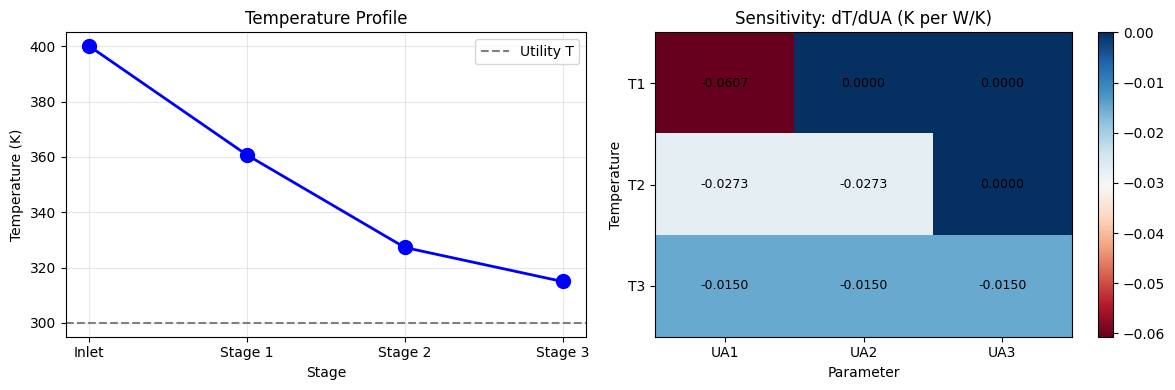

In [14]:
# Visualize sensitivity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Temperature profile
ax1 = axes[0]
stages = range(len(T_profile))
ax1.plot(stages, T_profile, 'bo-', markersize=10, linewidth=2)
ax1.axhline(300, color='gray', linestyle='--', label='Utility T')
ax1.set_xlabel('Stage')
ax1.set_ylabel('Temperature (K)')
ax1.set_title('Temperature Profile')
ax1.set_xticks(stages)
ax1.set_xticklabels(['Inlet'] + [f'Stage {i+1}' for i in range(len(params))])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Sensitivity heatmap
ax2 = axes[1]
im = ax2.imshow(sens_matrix, cmap='RdBu', aspect='auto')
ax2.set_xticks(range(len(params)))
ax2.set_xticklabels([f'UA{i+1}' for i in range(len(params))])
ax2.set_yticks(range(len(params)))
ax2.set_yticklabels([f'T{i+1}' for i in range(len(params))])
ax2.set_xlabel('Parameter')
ax2.set_ylabel('Temperature')
ax2.set_title('Sensitivity: dT/dUA (K per W/K)')
plt.colorbar(im, ax=ax2)

# Add values
for i in range(len(params)):
    for j in range(len(params)):
        ax2.text(j, i, f'{sens_matrix[i,j]:.4f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Chemical Engineering Example: Reactor Cascade Analysis

Analyze a cascade of CSTRs where we want derivatives of intermediate concentrations.

In [15]:
def cstr_cascade(params, feed):
    """
    Cascade of CSTRs with first-order reaction A -> B.
    
    params: dict with 'k' (rate constants), 'V' (volumes), 'T' (temperatures)
    feed: dict with 'C_A0' (feed concentration), 'F' (flow rate)
    
    Returns: (final_conversion, detailed_results)
    """
    k_values = params['k']
    V_values = params['V']
    T_values = params['T']
    
    C_A0, F = feed['C_A0'], feed['F']
    E_over_R = 5000.0  # Activation energy / R
    
    # Track all intermediate values
    results = {
        'C_A': [C_A0],      # Concentrations after each reactor
        'X': [0.0],         # Conversions
        'r': [],            # Reaction rates
        'tau': []           # Residence times
    }
    
    C_A = C_A0
    
    for i, (k0, V, T) in enumerate(zip(k_values, V_values, T_values)):
        tau = V / F
        k = k0 * jnp.exp(-E_over_R / T)  # Arrhenius
        
        # Steady-state CSTR: C_A_out = C_A_in / (1 + k*tau)
        C_A_out = C_A / (1 + k * tau)
        r = k * C_A_out  # Reaction rate
        X = 1 - C_A_out / C_A0  # Overall conversion
        
        results['C_A'].append(C_A_out)
        results['X'].append(X)
        results['r'].append(r)
        results['tau'].append(tau)
        
        C_A = C_A_out
    
    final_conversion = 1 - C_A / C_A0
    
    # Convert lists to arrays
    results = {k: jnp.array(v) for k, v in results.items()}
    
    return final_conversion, results

# System setup: 3 CSTRs in series
params = {
    'k': jnp.array([1e5, 1e5, 1e5]),       # Pre-exponential factors
    'V': jnp.array([10.0, 15.0, 20.0]),    # Volumes (m³)
    'T': jnp.array([350.0, 360.0, 370.0])  # Temperatures (K)
}
feed = {'C_A0': jnp.array(1.0), 'F': jnp.array(1.0)}  # mol/m³, m³/s

conversion, results = cstr_cascade(params, feed)

print("CSTR Cascade Results:")
print("=" * 60)
print(f"\nConcentration profile (mol/m³):")
for i, C in enumerate(results['C_A']):
    label = 'Feed' if i == 0 else f'After CSTR {i}'
    print(f"  {label}: C_A = {C:.4f}")

print(f"\nConversion profile:")
for i, X in enumerate(results['X']):
    if i > 0:
        print(f"  After CSTR {i}: X = {X:.4f} ({X*100:.1f}%)")

print(f"\nFinal conversion: {conversion:.4f} ({conversion*100:.1f}%)")

CSTR Cascade Results:

Concentration profile (mol/m³):
  Feed: C_A = 1.0000
  After CSTR 1: C_A = 0.6154
  After CSTR 2: C_A = 0.2571
  After CSTR 3: C_A = 0.0694

Conversion profile:
  After CSTR 1: X = 0.3846 (38.5%)
  After CSTR 2: X = 0.7429 (74.3%)
  After CSTR 3: X = 0.9306 (93.1%)

Final conversion: 0.9306 (93.1%)


In [16]:
# Sensitivity analysis: How do intermediate concentrations depend on temperatures?

def concentration_after_reactor(params, feed, reactor_idx):
    """Get concentration after a specific reactor."""
    _, results = cstr_cascade(params, feed)
    return results['C_A'][reactor_idx + 1]  # +1 because index 0 is feed

def compute_sensitivity_to_temperature(params, feed):
    """Compute dC_A_i / dT_j for all reactor pairs."""
    n_reactors = len(params['T'])
    
    sensitivity = jnp.zeros((n_reactors, n_reactors))
    
    for i in range(n_reactors):
        # Gradient of C_A after reactor i w.r.t. all temperatures
        def get_C_i(T_array):
            params_modified = {**params, 'T': T_array}
            return concentration_after_reactor(params_modified, feed, i)
        
        dC_dT = grad(get_C_i)(params['T'])
        sensitivity = sensitivity.at[i, :].set(dC_dT)
    
    return sensitivity

sens_T = compute_sensitivity_to_temperature(params, feed)

print("\nSensitivity: dC_A_i / dT_j (mol/m³ per K):")
print("=" * 60)
print(f"{'Conc.':<10}" + "".join(f"{'dC/dT'+str(j+1):>15}" for j in range(len(params['T']))))
print("-" * 60)
for i in range(len(params['T'])):
    print(f"C_A_{i+1:<6}" + "".join(f"{sens_T[i,j]:>15.6f}" for j in range(len(params['T']))))

print("\nKey insights:")
print("  - Negative values: higher T -> lower C_A (more reaction)")
print("  - Upper triangular structure: upstream T affects downstream C")
print("  - Diagonal dominance: each reactor most sensitive to its own T")


Sensitivity: dC_A_i / dT_j (mol/m³ per K):
Conc.              dC/dT1         dC/dT2         dC/dT3
------------------------------------------------------------
C_A_1           -0.009660       0.000000       0.000000
C_A_2           -0.004035      -0.005775       0.000000
C_A_3           -0.001089      -0.001559      -0.001850

Key insights:
  - Negative values: higher T -> lower C_A (more reaction)
  - Upper triangular structure: upstream T affects downstream C
  - Diagonal dominance: each reactor most sensitive to its own T


In [17]:
# Full sensitivity analysis: gradient of conversion and all intermediates
# w.r.t. all design parameters

def full_sensitivity_analysis(params, feed):
    """
    Compute sensitivities of all outputs to all inputs.
    """
    # Flatten parameters for easier differentiation
    n = len(params['T'])
    
    # Sensitivity of final conversion
    def get_conversion(p_flat):
        p = {'k': p_flat[:n], 'V': p_flat[n:2*n], 'T': p_flat[2*n:]}
        conv, _ = cstr_cascade(p, feed)
        return conv
    
    p_flat = jnp.concatenate([params['k'], params['V'], params['T']])
    
    # Gradient of conversion
    grad_conversion = grad(get_conversion)(p_flat)
    
    # Normalized sensitivities
    conv_value = get_conversion(p_flat)
    norm_sens = (p_flat / conv_value) * grad_conversion
    
    return {
        'grad_k': grad_conversion[:n],
        'grad_V': grad_conversion[n:2*n],
        'grad_T': grad_conversion[2*n:],
        'norm_k': norm_sens[:n],
        'norm_V': norm_sens[n:2*n],
        'norm_T': norm_sens[2*n:]
    }

sens = full_sensitivity_analysis(params, feed)

print("\nConversion Sensitivity Analysis:")
print("=" * 60)
print(f"\n{'Parameter':<10} {'dX/dp':<15} {'Normalized':<15} {'Interpretation'}")
print("-" * 60)

param_names = ['k1', 'k2', 'k3', 'V1', 'V2', 'V3', 'T1', 'T2', 'T3']
all_grads = jnp.concatenate([sens['grad_k'], sens['grad_V'], sens['grad_T']])
all_norms = jnp.concatenate([sens['norm_k'], sens['norm_V'], sens['norm_T']])

for name, g, n in zip(param_names, all_grads, all_norms):
    direction = "↑" if g > 0 else "↓" if g < 0 else "—"
    print(f"{name:<10} {g:<15.6f} {n:<15.4f} {direction} conversion")


Conversion Sensitivity Analysis:

Parameter  dX/dp           Normalized      Interpretation
------------------------------------------------------------
k1         0.000000        0.0287          ↑ conversion
k2         0.000000        0.0434          ↑ conversion
k3         0.000001        0.0544          ↑ conversion
V1         0.002668        0.0287          ↑ conversion
V2         0.002693        0.0434          ↑ conversion
V3         0.002533        0.0544          ↑ conversion
T1         0.001089        0.4096          ↑ conversion
T2         0.001559        0.6030          ↑ conversion
T3         0.001850        0.7356          ↑ conversion


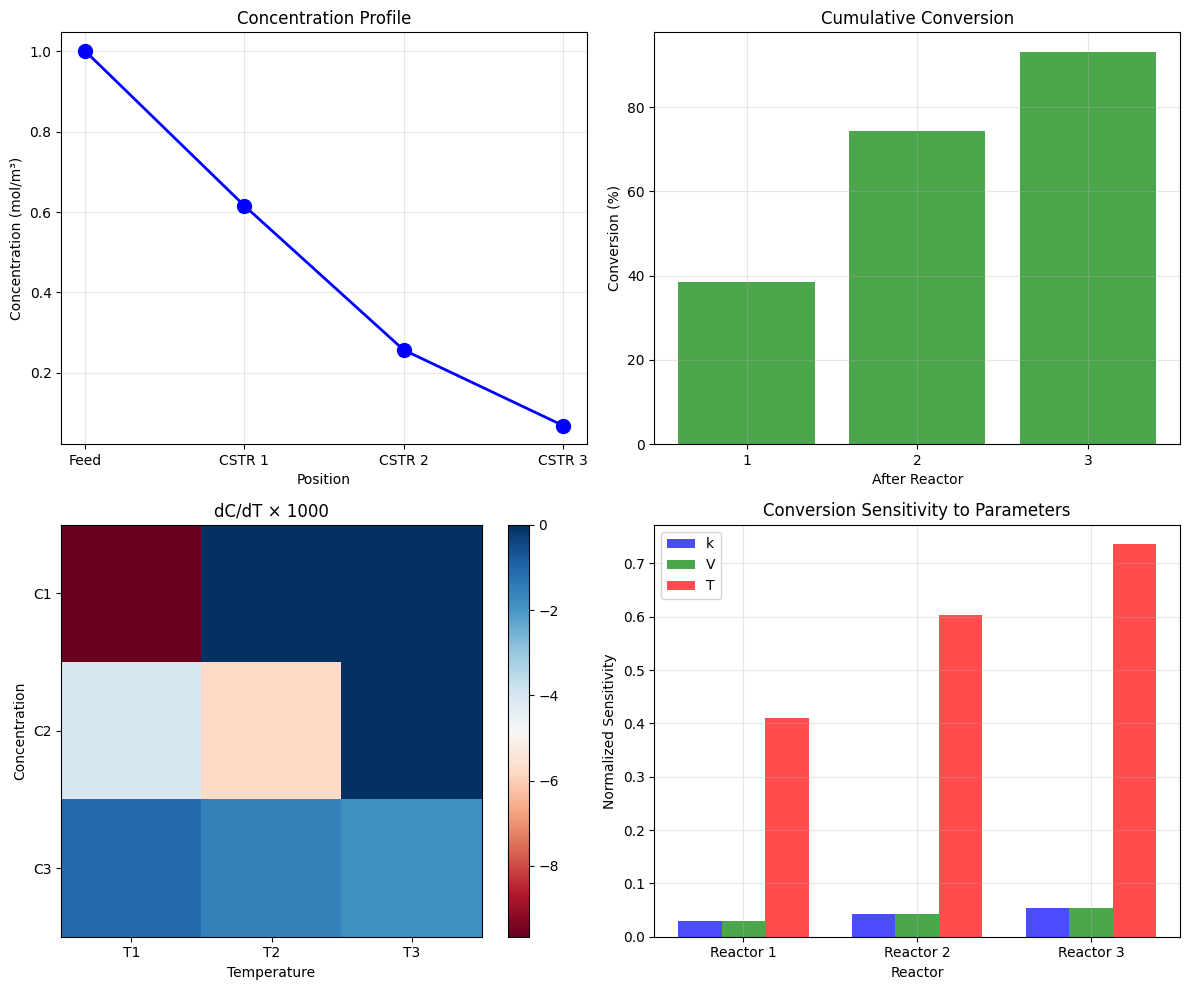

In [18]:
# Visualize the cascade and sensitivities
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Concentration profile
ax1 = axes[0, 0]
reactor_positions = range(len(results['C_A']))
ax1.plot(reactor_positions, results['C_A'], 'bo-', markersize=10, linewidth=2)
ax1.set_xlabel('Position')
ax1.set_ylabel('Concentration (mol/m³)')
ax1.set_title('Concentration Profile')
ax1.set_xticks(reactor_positions)
ax1.set_xticklabels(['Feed'] + [f'CSTR {i+1}' for i in range(len(params['T']))])
ax1.grid(True, alpha=0.3)

# Plot 2: Conversion profile
ax2 = axes[0, 1]
ax2.bar(range(1, len(results['X'])), results['X'][1:] * 100, color='green', alpha=0.7)
ax2.set_xlabel('After Reactor')
ax2.set_ylabel('Conversion (%)')
ax2.set_title('Cumulative Conversion')
ax2.set_xticks(range(1, len(results['X'])))
ax2.grid(True, alpha=0.3)

# Plot 3: Sensitivity heatmap (concentration to temperature)
ax3 = axes[1, 0]
im = ax3.imshow(sens_T * 1000, cmap='RdBu', aspect='auto')  # Scale for visibility
ax3.set_xticks(range(len(params['T'])))
ax3.set_xticklabels([f'T{i+1}' for i in range(len(params['T']))])
ax3.set_yticks(range(len(params['T'])))
ax3.set_yticklabels([f'C{i+1}' for i in range(len(params['T']))])
ax3.set_xlabel('Temperature')
ax3.set_ylabel('Concentration')
ax3.set_title('dC/dT × 1000')
plt.colorbar(im, ax=ax3)

# Plot 4: Normalized sensitivities bar chart
ax4 = axes[1, 1]
width = 0.25
x = jnp.arange(len(params['T']))
ax4.bar(x - width, sens['norm_k'], width, label='k', color='blue', alpha=0.7)
ax4.bar(x, sens['norm_V'], width, label='V', color='green', alpha=0.7)
ax4.bar(x + width, sens['norm_T'], width, label='T', color='red', alpha=0.7)
ax4.set_xlabel('Reactor')
ax4.set_ylabel('Normalized Sensitivity')
ax4.set_title('Conversion Sensitivity to Parameters')
ax4.set_xticks(x)
ax4.set_xticklabels([f'Reactor {i+1}' for i in range(len(params['T']))])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This tutorial covered techniques for accessing intermediate derivatives:

| Technique | Use Case | Code Pattern |
|-----------|----------|-------------|
| `has_aux=True` | Return intermediates during grad | `grad(f, has_aux=True)(x)` |
| `value_and_grad` | Get value + gradient efficiently | `value_and_grad(f)(x)` |
| `jacobian` on partial | Jacobian of intermediate | `jacobian(get_intermediate)(x)` |
| Custom VJP | Full control over backward pass | `@custom_vjp` with explicit gradient tracking |
| Structured output | Return intermediates as dict | `return output, {'h1': h1, ...}` |

### Key Takeaways

1. **Structure functions to expose intermediates**: Return `(output, aux_dict)` from the start
2. **Use `has_aux=True`**: JAX only differentiates through the first output
3. **Jacobians for vector intermediates**: Use `jacobian()` for multi-dimensional sensitivity
4. **Custom VJP for full control**: Can track/return gradient at any intermediate
5. **Engineering insight**: Intermediate sensitivities reveal which parameters matter where

### Chemical Engineering Applications

- **Reactor cascades**: How does conversion at each stage depend on operating conditions?
- **Heat exchanger networks**: Temperature sensitivity at each point
- **Distillation columns**: Composition profile sensitivity to reflux ratio
- **Control systems**: How do intermediate states respond to inputs?